# Correlation bar plot
In this example we will:
1. load interpolated time series data for two tags
2. split the datapoints into bins based on the values of the first tag
3. calculate an aggregated value (here the median) for the second tag
4. create a bar chart with bars for the tag 1 bins, showing and the aggregated value of tag 2

## Function for getting tag data
As a starting point, we implement a function to get time-series data directly from a tag. This function outputs DataFrame objects which we will use to create our plot.

In [2]:
import os
import time
from typing import List, Union
import pandas as pd
import requests
import urllib3


def get_data(
    tagnames: List[str],
    start: pd.Timestamp,
    end: pd.Timestamp,
    freq: pd.Timedelta,
    tz: Union[str, None] = "UTC",
    verify: bool = False,
) -> pd.DataFrame:
    """
    Retrieve interpolated time series data from selected tags, paging transparently
    for long time ranges by following the API's `nextStartDate`.
    """
    # 1) Localize / round inputs
    if tz:
        if start.tzinfo is None:
            start = start.tz_localize(tz)
        if end.tzinfo is None:
            end = end.tz_localize(tz)
    start = start.round(freq)
    end   = end.round(freq)

    # 2) Auth + optional SSL‐skip
    headers = {"Authorization": f"Bearer {os.environ['KERNEL_USER_TOKEN']}"}
    if not verify:
        urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

    series_list = []
    for tagname in tagnames:
        # fetch tag metadata
        details = requests.get(
            f"{os.environ['KERNEL_SERVER_URL']}/hps/api/tags/details",
            headers=headers,
            params={"tagName": tagname},
            verify=verify,
        ).json()

        chunks = []
        next_start = start

        while True:
            payload = {
                "tag": {
                    "id": details["id"],
                    "shift": 0,
                    "interpolationType": details["interpolationType"],
                },
                "timePeriod": {
                    "startDate": next_start.isoformat(timespec="milliseconds"),
                    "endDate":   end.isoformat(timespec="milliseconds"),
                },
                "step": int(freq.total_seconds()),
            }
            data = requests.post(
                f"{os.environ['KERNEL_SERVER_URL']}/compute/interpolatedData/paged",
                headers=headers,
                json=payload,
                verify=verify,
            ).json()

            # **NEW**: only build a chunk when there *are* values
            vals = data.get("values", [])
            if vals:
                chunk = (
                    pd.DataFrame(vals)
                      .assign(ts=lambda df: pd.to_datetime(df["ts"]))
                      .set_index("ts")["value"]
                )
                chunks.append(chunk)

            # advance to next page (or break if none)
            next_sd = data.get("nextStartDate")
            if not next_sd:
                break

            next_start = pd.to_datetime(next_sd)
            if next_start >= end:
                break

            time.sleep(0.1)

        # if we never got *any* data, make an empty Series
        if chunks:
            tag_series = pd.concat(chunks)
        else:
            tag_series = pd.Series(dtype=float, name=tagname)

        tag_series.name = tagname

        # map codes → names for STRING/DIGITAL tags
        if details.get("type") in ("DIGITAL", "STRING"):
            states = {s["Code"]: s["Name"] for s in details.get("States", [])}
            tag_series = tag_series.map(states)

        series_list.append(tag_series)

    # combine into one DataFrame, convert tz
    df = pd.concat(series_list, axis=1)
    if tz:
        df.index = df.index.tz_convert(tz)

    return df

## Plot

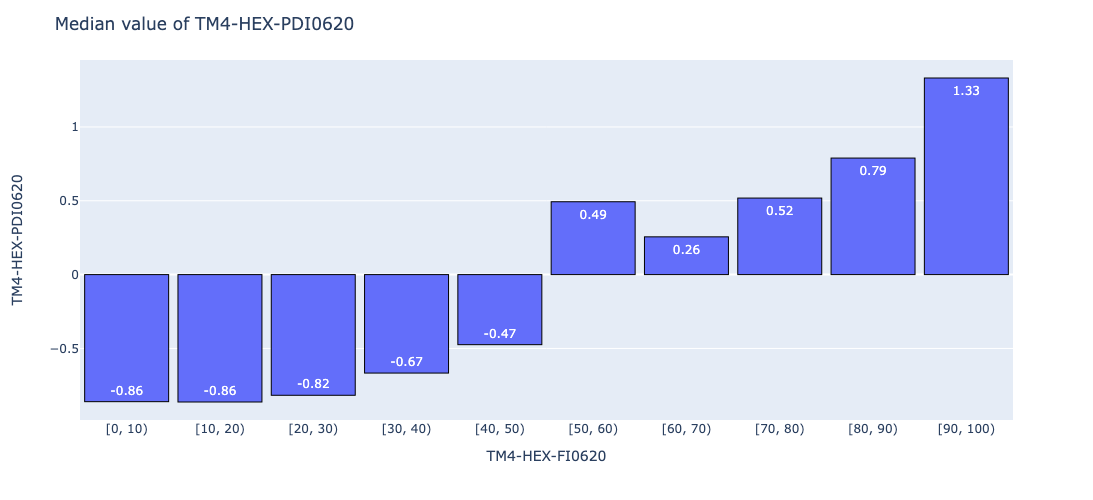

In [11]:
import plotly.express as px

target_tag_name = "TM4-HEX-PDI0620"
binning_tag_name = "TM4-HEX-FI0620"

df = get_data(
    tagnames=[target_tag_name, binning_tag_name],
    start=pd.Timestamp("2023-04-01"),
    end=pd.Timestamp("2023-05-01"),
    freq=pd.Timedelta("5m"),
    tz="Europe/Brussels"
)

# Cut 
df["bin"] = pd.cut(
    df[binning_tag_name],
    right=False,  # Make inclusive from the left side so 0 values are included
    bins=range(0, 101, 10),  # Bins from [0, 10) to [90, 100)
)

df_binned = (
    df.groupby("bin")
    .median()  # Median of interpolated points
)

fig = px.bar(
    x=df_binned.index.astype("string"),
    y=df_binned[target_tag_name],
)

# Show values inside each bin
fig.update_traces(
    texttemplate="%{y:.2f}",
    textposition="inside",
    marker_line_color="black",  # optional: outline for clarity
    marker_line_width=1
)

fig.update_layout(
    title=f"Median value of {target_tag_name}",
    xaxis_title=binning_tag_name,
    yaxis_title=target_tag_name,
    bargap=0.1,
    height=500,
    width=1000,
)

fig.show()